# 12주차 텍스트 데이터 분석 정리

## 학습 목표
- 파이프라인 이해 (수집->전처리->벡터화->모델링)
- 전처리 마스터 (노이즈를 제거하고 의미 있는 단어를 추출하는 방법 습득)
- TF-IDF 해석 (단순 빈도를 넘어, 단어의 진짜 중요도를 수치화하는 원리 이해)
- 감성분석 실전 (머신러닝을 활용해 긍정/부정을 분류하고 한계를 분석)

## 강의 핵심 주제
1. 텍스트 전처리
2. TF-IDF
3. 감성분석(Sentiment Analysis)

> 대표 예시
> - 정제 전: `배송이 느리고 포장이 별로였습니다!!!`
> - 정제 후: `배송이 느리고 포장이 별로였습니다`
> - TF-IDF 직관 예시: `영화 정말 최고`, `영화 정말 별로`


## 1. 텍스트 데이터 분석의 전체 흐름

강의 흐름은 다음과 같습니다.

1. **텍스트 전처리**
   - 정제(Cleaning)
   - 소문자화
   - 특수문자/숫자 제거
   - 토큰화(Tokenization)
   - 불용어 제거(Stopwords)
2. **텍스트 수치화**
   - Bag-of-Words의 한계 이해
   - TF-IDF로 단어 중요도 반영
3. **감성분석 모델링**
   - 전처리된 텍스트를 벡터화
   - 분류 모델 학습(Logistic Regression)
   - 성능 평가 및 해석
4. **심화 분석**
   - 오분류 사례 분석
   - n-gram 비교
   - Random Forest와 비교

핵심 메시지는 **전처리 → 벡터화 → 학습 → 평가 → 해석** 입니다.


시험 나올 수 있는 부분

정형 데이터와 텍스트 데이터의 차이점
-> 정형 데이터(엑셀, DB)는 전처리 후 바로 모델에 입력할 수 있습니다. 하지만 텍스트 데이터는 컴퓨터가 스스로 이해할 수 없으므로, 반드시 숫자 벡터(vector)로 변환하는 과정이 필수적이다

## 2. 왜 텍스트 전처리가 필요한가

텍스트는 그대로는 모델이 다루기 어렵습니다. 전처리는 다음 목적을 가집니다
- 대소문자 혼재
- 불필요한 특수문자
- 의미 없는 단어/조사

- 입력: `배송이 느리고 포장이 별로였습니다!!!`
- 정제 후: `배송이 느리고 포장이 별로였습니다`

모델이 불필요한 노이즈를 무시하고 "의미 있는 패턴(단어)"에만 집중하도록 돕는 필수 정제 과정입니다.


## 3. 텍스트 전처리 핵심 개념 정리

### 3-1. 정제(Cleaning)
- 특수문자 제거
- 숫자 제거
- 불필요한 공백 제거
- 대소문자 차이와 무의미한 특수문자를 제거하여 데이터의 복잡도를 낮춥니다.
- 영문 텍스트에서는 `Good`와 `good`을 같은 단어로 보기 위해 소문자화가 필요합니다.

### 3-2. 토큰화(Tokenization)
- 문장을 분석의 기본 단위인 단어(Token)으로 쪼개는 과정입니다.
- text.split()

### 3-3. 불용어 제거(Stopwords)
- 분석에 큰 도움이 되지 않는 단어를 제거합니다.
- 이, 은, 는, 하지만 등 문법적 역할만 하고 핵심 의미가 없는 단어를 제거합니다.


## 4. Bag-of-Words의 한계와 TF-IDF

### Bag-of-Words의 한계
Bag-of-Words는 단어가 몇 번 등장했는지만 보기 때문에,

- 문맥과 단어의 순서를 완전히 무시함
- 모든 단어를 동일하게 취급함
- '하다', '너무'같이 자주 모든 문서에 흔하게 등장하는 무의미한 단어의 중요도가 과도하게 커집니다.
- 해결책: 단순 빈도를 넘어 단어의 진짜 정보 가치를 측정하는 TF-IDF가 필요합니다.

### TF-IDF의 직관
TF-IDF는 다음 아이디어를 사용합니다.

- 한 문서 안에서 자주 등장하면 중요할 가능성이 큼 (TF)
- 다른 모든 문서에서는 희귀한 단어인가? (IDF)

즉, **해당 문서에서는 자주 나오지만 전체 문서에서는 흔하지 않은 단어**에 높은 가중치를 줍니다.

### 강의 예시
- 문서1: `영화 정말 최고`
- 문서2: `영화 정말 별로`

여기서 `영화`, `정말`보다 `최고`, `별로`가 감성 구분에 더 중요할 수 있습니다.


## 5. 감성분석(Sentiment Analysis)이란

감성분석은 텍스트에 담긴 주관적인 감정, 태도, 의견을 분석하여 범주를 분류하는 머신러닝 작업.
이번 실습의 목표는 가장 단순한 형태인 이진분류(binary Classification)

- `1`: 긍정
- `0`: 부정

### 감성분석 전체 파이프라인
1. 텍스트 데이터(Reviews & Labels)
2. TF-IDF 벡터 변환(TfidfVectorizer)
3. 데이터 분할(Train/Test Split)
4. 로지스틱 회귀모델

로지스틱 회귀의 계수를 통해 긍정 부정 판단 가능
- (-)음수 계수: 모델이 부정으로 판단하게 만드는 단어
- (+)양수 계수: 모델이 긍정으로 판단하게 만드는 단어

강의에서 강조하는 포인트는 **좋은 전처리와 적절한 벡터화가 모델 성능과 해석 가능성을 크게 좌우한다**는 점입니다.

단순 TF-IDF + 머신러닝 모델이 실패하는 대표적인 오분류 사례들:
1. 반어법 / 비꼬기
2. 복합 문맥
3. 도메인(영역) 차이
4. 극도로 짧은 문장


In [1]:
# 1. 라이브러리 로드
import numpy as np
import pandas as pd
import re                  # 정규표현식(Regular Expression) 처리 라이브러리 - 문자열에서 특정 패턴을 찾거나, 바꾸거나, 제거하는 역할
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

pd.set_option('display.max_columns', 200)
print('Ready')

Ready


## 6. 데이터 로드

강의 자료에서 사용되는 데이터는 `week12_reviews_sentiment.csv`이며,
일반적으로 다음 두 컬럼을 가진다고 볼 수 있습니다.

- `review_text`: 리뷰 텍스트
- `sentiment`: 감성 라벨 (1=긍정, 0=부정)

아래 코드는 다양한 컬럼명에 대응하도록 작성되어 있습니다.


In [2]:
DATA_PATH = 'week12_reviews_sentiment.csv'

df = pd.read_csv(DATA_PATH)
print('shape:', df.shape)
display(df.head())
print(df.columns.tolist())

shape: (240, 4)


,review_id,product,review_text,sentiment
0,R0007,전동칫솔,이번에 전동칫솔 관련 리뷰: 가격은 비싸지만 성능은 좋아서 만족합니다.,1
1,R0047,커피머신,공기청정기 구매했는데 착용감이 편하고 소음이 적고 주변에 추천했습니다.,1
2,R0079,스니커즈,노트북 구매했는데 만족도가 높고 배터리가 오래가고 주변에 추천했습니다.,1
3,R0003,전동칫솔,전동칫솔 관련 리뷰: 디자인은 예쁜데 내구성이 약해서 아쉽네요.,0
4,R0076,향수,무선 이어폰 구매했는데 성능이 아쉽고 사용법이 복잡하고 품질 관리가 필요해 보입니다.,0


['review_id', 'product', 'review_text', 'sentiment']


In [3]:
df['sentiment'].value_counts()

sentiment
1    121
0    119
Name: count, dtype: int64

In [4]:
#3. 텍스트 전처리
def clean_text(text: str) -> str:      # 문자열(text)
    # 1) 영문 소문자화
    text = text.lower()      # 영문자를 모두 소문자
    
    # 2) 한글/영문/공백만 남김
    text = re.sub(r"[^가-힣a-z\s]", " ", text)
    
    # 3) 연속 공백 정리
    text = re.sub(r"\s+", " ", text)      # 공백 여러 개를 하나로
    
    return text.strip()      # 앞뒤 공백 제거 후 반환

df['text_clean'] = df['review_text'].apply(clean_text)

# 전/후 비교(3개)
for i in range(3):      # 상위 3개 출력
    print('---')
    print('RAW  :', df.loc[i, 'review_text'])
    print('CLEAN:', df.loc[i, 'text_clean'])


---
RAW  : 이번에 전동칫솔 관련 리뷰: 가격은 비싸지만 성능은 좋아서 만족합니다.
CLEAN: 이번에 전동칫솔 관련 리뷰 가격은 비싸지만 성능은 좋아서 만족합니다
---
RAW  : 공기청정기 구매했는데 착용감이 편하고 소음이 적고 주변에 추천했습니다.
CLEAN: 공기청정기 구매했는데 착용감이 편하고 소음이 적고 주변에 추천했습니다
---
RAW  : 노트북 구매했는데 만족도가 높고 배터리가 오래가고 주변에 추천했습니다.
CLEAN: 노트북 구매했는데 만족도가 높고 배터리가 오래가고 주변에 추천했습니다


In [6]:
#4. train/test split
x = df['text_clean']
y = df['sentiment']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y
)

print('[train] class ratio')
print(y_train.value_counts(normalize=True).round(3))
print('\n[test] class ratio')
print(y_test.value_counts(normalize=True).round(3))


[train] class ratio
sentiment
1    0.506
0    0.494
Name: proportion, dtype: float64

[test] class ratio
sentiment
1    0.5
0    0.5
Name: proportion, dtype: float64


## 9. TF-IDF 벡터화

강의 실습 포인트
- `min_df=2`: 너무 희귀한 단어 제거
- `max_df=0.95`: 너무 흔한 단어 제거
- `ngram_range=(1,1)`: 기본 unigram

필요하면 이후 bigram도 비교합니다.

- 단어를 몇 개씩 묶어서 feature로 사용할 것인가
    - ngram_range=min(min_n, max_n)
    - (1,1)은 단어 하나
    - (1,2)는 단어+문맥
    - (2,2)는 문맥만 사용

In [9]:
#5. TF-IDF 벡터화
vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,          # 최소 2개 문서 이상 등장한 단어만 사용(너무 드문 단어 제거)
    max_df=0.95        # 전체 문서의 95% 이상 등장한 단어 제거(너무 흔한 단어 제거)
)

x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

print('train tfidf shape:', x_train_tfidf.shape)
print('test tfidf shape :', x_test_tfidf.shape)
print('vocab size:', len(vectorizer.get_feature_names_out()))  # get_feature_names_out(): TF-IDF vocabulary(단어 목록) 추출


train tfidf shape: (180, 154)
test tfidf shape : (60, 154)
vocab size: 154


## 10. 로지스틱 회귀 기반 감성분석 모델 학습

강의에서 로지스틱 회귀는 다음 이유로 중요합니다.

- 계산이 빠름
- 고차원 희소 데이터에 강함
- 계수(coefficient)를 통해 단어 중요도 해석이 쉬움


In [10]:
#6. Logistic Regression
clf = LogisticRegression(max_iter=2000)
clf.fit(x_train_tfidf, y_train)

pred = clf.predict(x_test_tfidf)

print(classification_report(y_test, pred, digits=3))
print('F1:', round(float(f1_score(y_test, pred)), 4))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        30
           1      1.000     1.000     1.000        30

    accuracy                          1.000        60
   macro avg      1.000     1.000     1.000        60
weighted avg      1.000     1.000     1.000        60

F1: 1.0


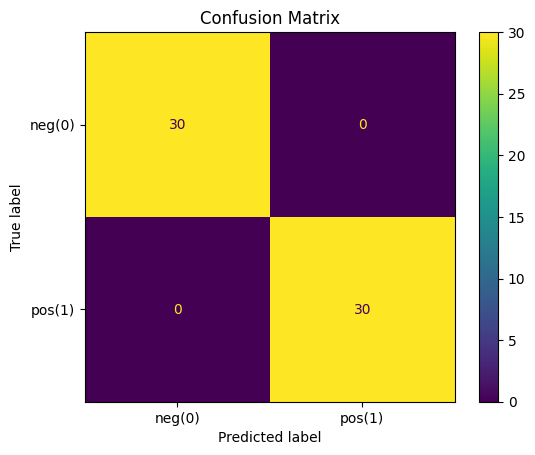

cm:
 [[30  0]
 [ 0 30]]


In [12]:
#7. 혼동행렬 시각화 - Logistic Regression
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['neg(0)', 'pos(1)'])
disp.plot(values_format='d')
plt.title('Confusion Matrix')
plt.show()

print('cm:\n', cm)

In [13]:
#8. 단어 중요도(계수) 확인
# get_feature_names_out(): TF-IDF vocabulary(단어 목록) 추출
feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]         # Logistic Regression의 단어별 회귀계수 추출
coef_df = pd.DataFrame({'term': feature_names, 'coef': coefs})

print('Top positive terms (toward sentiment=1)')
coef_df.sort_values('coef', ascending=False).head(10)


Top positive terms (toward sentiment=1)


,term,coef
118,정말,1.123149
44,만족합니다,1.036434
135,추천했습니다,0.978294
124,주변에,0.978294
111,있고,0.976679
103,은은하고,0.944377
102,오래가고,0.895377
4,간단하고,0.881381
48,매우,0.851693
122,좋아요,0.851693


In [14]:
print('Top negative terms (toward sentiment=0)')
coef_df.sort_values('coef', ascending=True).head(10)


Top negative terms (toward sentiment=0)


,term,coef
29,너무,-1.198765
90,아쉽네요,-0.984439
89,아쉽고,-0.962934
34,다시는,-0.960214
56,별로예요,-0.915952
33,늦고,-0.858926
137,크고,-0.857458
87,실망했습니다,-0.855444
125,중입니다,-0.840682
16,교환,-0.840682


In [15]:
# 긍정/부정에 기여하는 단어 추출
feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

coef_df = pd.DataFrame({
    "term": feature_names,
    "coef": coefs
})

top_pos = coef_df.sort_values("coef", ascending=False).head(20)
top_neg = coef_df.sort_values("coef", ascending=True).head(20)

print("Top Positive Terms")
display(top_pos)

print("Top Negative Terms")
display(top_neg)


Top Positive Terms


,term,coef
118,정말,1.123149
44,만족합니다,1.036434
135,추천했습니다,0.978294
124,주변에,0.978294
111,있고,0.976679
103,은은하고,0.944377
102,오래가고,0.895377
4,간단하고,0.881381
48,매우,0.851693
122,좋아요,0.851693


Top Negative Terms


,term,coef
29,너무,-1.198765
90,아쉽네요,-0.984439
89,아쉽고,-0.962934
34,다시는,-0.960214
56,별로예요,-0.915952
33,늦고,-0.858926
137,크고,-0.857458
87,실망했습니다,-0.855444
125,중입니다,-0.840682
16,교환,-0.840682


## 12. 워드클라우드 시각화

강의에서는 단어 중요도를 더 직관적으로 보기 위해 워드클라우드 같은 시각화도 활용할 수 있습니다.

> 주의: 한글 워드클라우드는 실행 환경에 따라 한글 폰트 설정이 필요할 수 있습니다.


In [22]:
# 예시: 패키지 설치 시
!python3 -m pip install WordCloud



[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [23]:
# WordCloud 설치
!pip3 -q install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Colab 한글 폰트 설치
!apt-get -qq install fonts-nanum
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# 긍정/부정 단어별 가중치 딕셔너리 생성
positive_words = top_pos.set_index("term")["coef"].to_dict()

# 부정 단어는 계수가 음수이므로 절댓값으로 변환
negative_words = top_neg.copy()
negative_words["coef_abs"] = negative_words["coef"].abs()
negative_words = negative_words.set_index("term")["coef_abs"].to_dict()



[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
zsh:1: command not found: apt-get


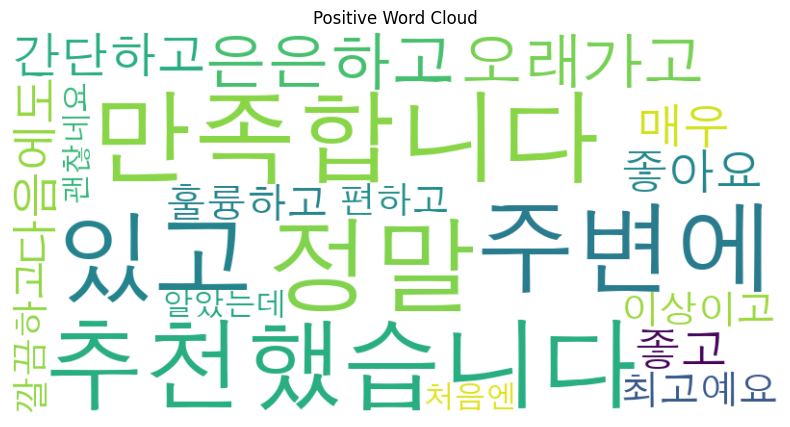

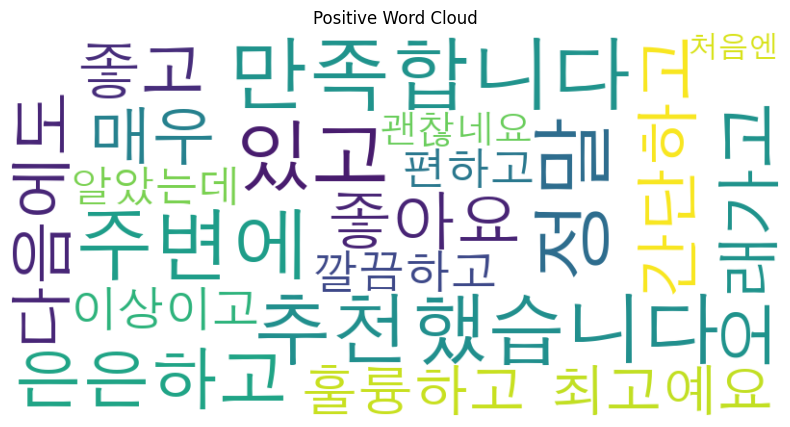

In [26]:
# Mac(macOS) 기본 한글 폰트 경로로 설정 변경
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"

# 이후 긍정 워드클라우드 실행
wc_pos = WordCloud(
    font_path=font_path,
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(positive_words)

plt.figure(figsize=(10, 5))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Word Cloud")
plt.show()
# Mac(macOS) 기본 한글 폰트 경로로 설정 변경
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"

# 이후 긍정 워드클라우드 실행
wc_pos = WordCloud(
    font_path=font_path,
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(positive_words)

plt.figure(figsize=(10, 5))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Word Cloud")
plt.show()


## 13. 오분류 사례 분석

강의에서는 단순 TF-IDF + 선형 분류기 조합이 다음 경우에 약할 수 있다고 봅니다.

- 긍정/부정 단어가 함께 등장하는 문장
- `~지만`, `그런데` 같은 대비 표현
- `나쁘진 않지만` 같은 완곡한 부정
- 반어법

아래 코드로 실제 오분류 사례를 확인할 수 있습니다.


In [ ]:
result_df = pd.DataFrame({
    'review_text': X_test.values,
    'true': y_test.values,
    'pred': y_pred
})

misclassified = result_df[result_df['true'] != result_df['pred']].copy()
print('오분류 개수:', len(misclassified))
display(misclassified.head(20))

In [ ]:
# 예측 확률까지 함께 보면 왜 헷갈렸는지 더 잘 볼 수 있습니다.
y_prob = log_reg.predict_proba(X_test_tfidf)[:, 1]

result_df = pd.DataFrame({
    'review_text': X_test.values,
    'true': y_test.values,
    'pred': y_pred,
    'pred_prob_positive': y_prob
})

misclassified = result_df[result_df['true'] != result_df['pred']].copy()
display(misclassified.sort_values('pred_prob_positive').head(10))
display(misclassified.sort_values('pred_prob_positive', ascending=False).head(10))

## 15. 심화 실습 2: Random Forest와 비교

강의 후반에서는 선형 모델(Logistic Regression)과 트리 기반 모델(Random Forest)을 비교하는 흐름도 다룹니다.

비교 포인트:
- 성능 차이
- 해석 방식 차이
- 텍스트 희소 행렬에서 어떤 모델이 더 안정적인지


In [28]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest 모델 학습
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(x_train_tfidf, y_train)

pred_rf = rf.predict(x_test_tfidf)

print("Random Forest Classification Report")
print(classification_report(y_test, pred_rf, digits=3))

print("F1:", round(float(f1_score(y_test, pred_rf)), 4))


Random Forest Classification Report
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        30
           1      1.000     1.000     1.000        30

    accuracy                          1.000        60
   macro avg      1.000     1.000     1.000        60
weighted avg      1.000     1.000     1.000        60

F1: 1.0


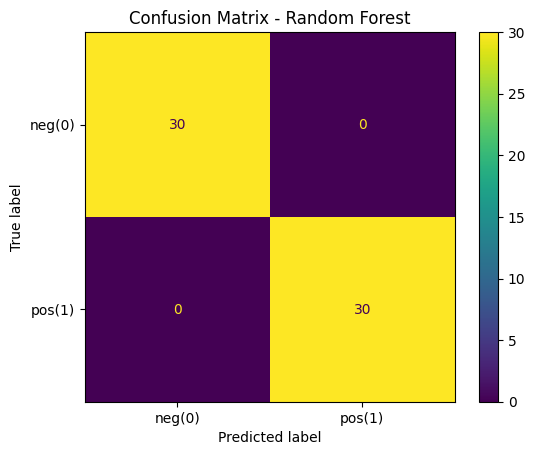

In [29]:
# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["neg(0)", "pos(1)"]
)

disp_rf.plot(values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [30]:
compare_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "F1-score": [
        f1_score(y_test, pred),
        f1_score(y_test, pred_rf)
    ]
})

compare_df


,Model,F1-score
0,Logistic Regression,1.0
1,Random Forest,1.0


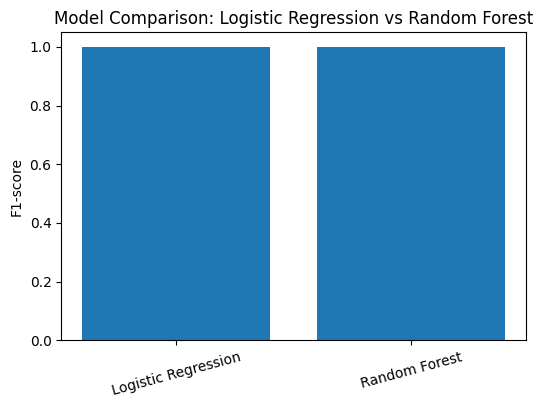

In [31]:
plt.figure(figsize=(6, 4))
plt.bar(compare_df["Model"], compare_df["F1-score"])
plt.ylim(0, 1.05)
plt.ylabel("F1-score")
plt.title("Model Comparison: Logistic Regression vs Random Forest")
plt.xticks(rotation=15)
plt.show()


In [32]:
rf_importance = pd.DataFrame({
    "term": feature_names,
    "importance": rf.feature_importances_
})

top_rf_terms = rf_importance.sort_values("importance", ascending=False).head(20)

display(top_rf_terms)


,term,importance
29,너무,0.042813
90,아쉽네요,0.033006
87,실망했습니다,0.024732
125,중입니다,0.023585
89,아쉽고,0.022873
34,다시는,0.021936
16,교환,0.021560
118,정말,0.020518
150,환불,0.018112
145,필요해,0.018108
